# DermaMNIST CNN model development and selection

This notebook explores different CNN configurations and training strategies for the **DermaMNIST 64×64** image classification task.

The experiments investigate the effect of class imbalance handling, data augmentation, network architecture, and optimisation strategies on CNN performance. Several model configurations are trained and compared using validation performance, with **macro-F1** used as the primary evaluation metric due to the imbalanced class distribution.

The results of these experiments are used to select the final CNN configuration for the local baseline and subsequent distributed training experiments.

The test set is not used during model development or selection.

### Dataset

DermaMNIST is part of the **MedMNIST+** collection and is derived from the **HAM10000** dataset of dermatoscopic images of pigmented skin lesions. Official destribution link: https://zenodo.org/records/10519652

* **Task:** multiclass image classification
* **Number of classes:** 7
* **Total images:** 10,015
* **Image type:** RGB dermatoscopic images
* **Image resolution:** 64 × 64 pixels
* **Training images:** 7,007
* **Validation images:** 1,003
* **Test images:** 2,005

The 64×64 version is selected because it provides a substantially more realistic image-classification workload than MNIST while remaining within the project's recommended dataset size of less than approximately 200 MB.

#### Dataset License: 

DermaMNIST is distributed under the *Creative Commons Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)* license.

This permits use, sharing and adaptation subject to the license conditions, including:

- Attribution: appropriate credit must be given to the dataset creators and source.
- Non-commercial use: the dataset may not be used for commercial purposes.
- License notice: the applicable license and any relevant changes must be indicated when redistributing or adapting the material.

The dataset is used here for academic research and educational purposes.

### Install MedMNIST

In [2]:
# pip install medmnist

In [71]:
import medmnist
from medmnist import DermaMNIST

import os
import time
import random
import copy
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import DataLoader, WeightedRandomSampler

from sklearn.metrics import classification_report, confusion_matrix, f1_score

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

print("MedMNIST version:", medmnist.__version__)

MedMNIST version: 3.0.2


### Download DermaMNIST 64×64

In [2]:
train_dataset = DermaMNIST(split="train", size=64, download=True)
val_dataset = DermaMNIST(split="val", size=64, download=True)
test_dataset = DermaMNIST(split="test", size=64, download=True)

In [3]:
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 7007
Validation: 1003
Test: 2005


In [4]:
# Inspect the dataset structure
print("Dataset type:", type(train_dataset))
print("Number of samples:", len(train_dataset))

image, label = train_dataset[0]

print("Image type:", type(image))
print("Image size:", image.size)
print("Image mode:", image.mode)
print("Label:", label)
print("Label type:", type(label))

Dataset type: <class 'medmnist.dataset.DermaMNIST'>
Number of samples: 7007
Image type: <class 'PIL.Image.Image'>
Image size: (64, 64)
Image mode: RGB
Label: [0]
Label type: <class 'numpy.ndarray'>


In [5]:
# where the physical dataset file is located
print("Root:", train_dataset.root)
print("Dataset root contents:", os.listdir(train_dataset.root))
print("Current working directory:", os.getcwd())

Root: /home/hduser/.medmnist
Dataset root contents: ['dermamnist_64.npz']
Current working directory: /home/hduser/Desktop/CA1


In [6]:
# check the actual .npz file
dataset_file = Path(train_dataset.root) / "dermamnist_64.npz"

file_size_mb = dataset_file.stat().st_size / (1024 ** 2)

print("Dataset file:", dataset_file)
print(f"File size: {file_size_mb:.2f} MB")

Dataset file: /home/hduser/.medmnist/dermamnist_64.npz
File size: 95.49 MB


In [7]:
# inspect what's inside the archive without extracting it
with np.load(dataset_file) as data:
    print("Files in archive:")
    for key in data.files:
        print(f"  {key}: {data[key].shape}, {data[key].dtype}")

Files in archive:
  train_images: (7007, 64, 64, 3), uint8
  train_labels: (7007, 1), uint8
  val_images: (1003, 64, 64, 3), uint8
  val_labels: (1003, 1), uint8
  test_images: (2005, 64, 64, 3), uint8
  test_labels: (2005, 1), uint8


Images are stored as unsigned 8-bit integer (uint8) RGB arrays.

The dataset remains in its compressed `.npz` format rather than being extracted into individual image files. This avoids creating thousands of small files and provides a compact source that can later be transfered to distributed storage.

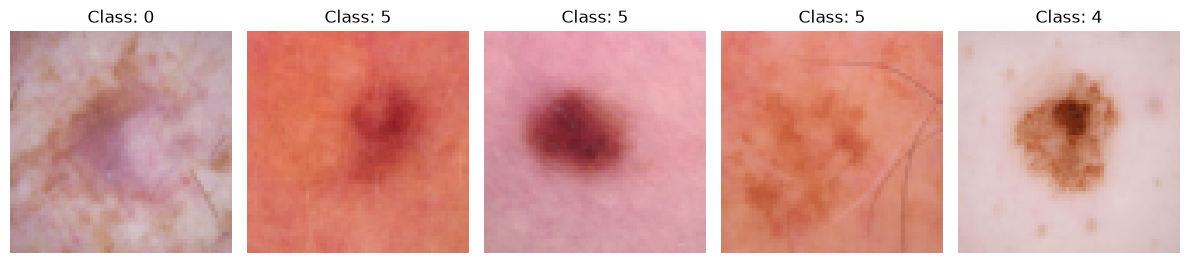

In [8]:
# let's actually look at some images
fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for i in range(5):
    image, label = train_dataset[i]
    
    axes[i].imshow(image)
    axes[i].set_title(f"Class: {label[0]}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [9]:
# MedMNIST provides the class information through the dataset metadata 
# let's inspect the class labels
print("Number of classes:", len(train_dataset.info["label"]))
print("\nClass labels:")

for key, name in train_dataset.info["label"].items():
    print(f"{key}: {name}")

Number of classes: 7

Class labels:
0: actinic keratoses and intraepithelial carcinoma
1: basal cell carcinoma
2: benign keratosis-like lesions
3: dermatofibroma
4: melanoma
5: melanocytic nevi
6: vascular lesions


In [10]:
# let's also count the training examples in each class to see if there's any significant class imbalance
train_labels = train_dataset.labels.flatten()

class_counts = Counter(train_labels)

print("Training class distribution:\n")

for class_id in sorted(class_counts):
    count = class_counts[class_id]
    percentage = count / len(train_labels) * 100
    
    print(f"{class_id}: {count:4d} ({percentage:5.2f}%)")

Training class distribution:

0:  228 ( 3.25%)
1:  359 ( 5.12%)
2:  769 (10.97%)
3:   80 ( 1.14%)
4:  779 (11.12%)
5: 4693 (66.98%)
6:   99 ( 1.41%)


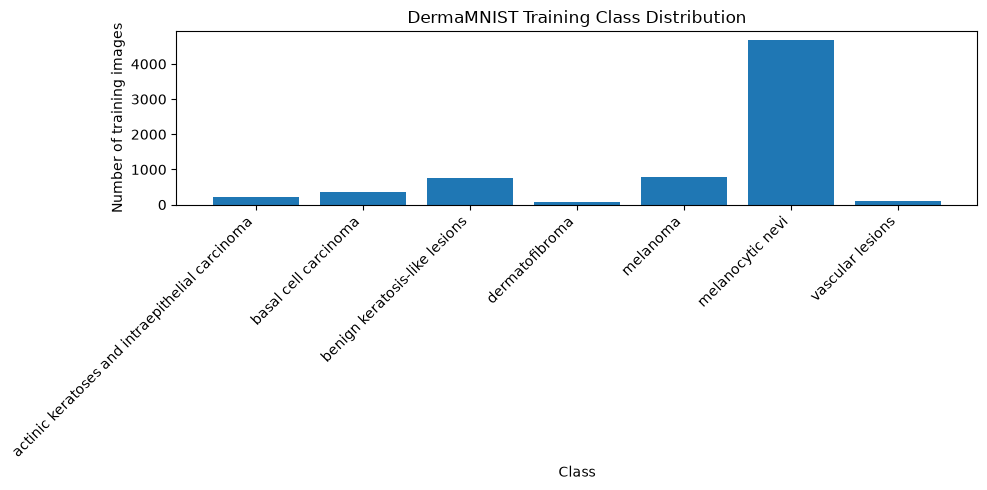

In [11]:
# visualise the imbalance
class_names = [train_dataset.info["label"][str(i)] for i in range(7)]
counts = [class_counts[i] for i in range(7)]

plt.figure(figsize=(10, 5))
plt.bar(range(7), counts)

plt.xticks(range(7), class_names, rotation=45, ha="right")

plt.ylabel("Number of training images")
plt.xlabel("Class")
plt.title("DermaMNIST Training Class Distribution")

plt.tight_layout()
plt.show()

The dataset is highly imbalanced, with melanocytic nevi (Class 5) making up ~67% of the training set, while dermatofibroma (Class 3) and vascular lesions (Class 6) each account for only 1–1.5%.

Because of this imbalance, classification accuracy alone may provide an incomplete assessment of model performance. In addition to accuracy, the experiment will consider class-sensitive metrics such as calculating macro-F1 score for each of the 7 classes and taking the unweighted mean of those seven F1 scores. We're interested in whether the CNN can learn the multiclass problem as a whole, rather than simply optimise performance on the most common nevi class.

### Image Preprocessing

The raw DermaMNIST images are stored as 64×64 RGB `uint8` images.

For CNN training, the images will be converted to PyTorch tensors and normalised.


In [12]:
train_images = train_dataset.imgs

print("Shape:", train_images.shape)
print("dtype:", train_images.dtype)
print("Pixel range:", train_images.min(), "to", train_images.max())

Shape: (7007, 64, 64, 3)
dtype: uint8
Pixel range: 0 to 255


In [13]:
# calculate the per-channel mean and standard deviation
train_images_float = train_images.astype(np.float32) / 255.0

mean = train_images_float.mean(axis=(0, 1, 2))
std = train_images_float.std(axis=(0, 1, 2))

print("Mean:", mean)
print("Std:", std)

Mean: [0.5845583  0.58314306 0.5845583 ]
Std: [0.21778087 0.15745011 0.16998562]


In [14]:
# use calculated values to standardise the input images before CNN training
transform = transforms.Compose([
    transforms.ToTensor(),   # 3 × 64 × 64
    # ToTensor() scales input image to [0.0, 1.0]
    transforms.Normalize(mean=mean.tolist(), std=std.tolist())
])

In [15]:
# apply transform
train_dataset_tensor = DermaMNIST(split="train", size=64, transform=transform, download=False)
val_dataset_tensor = DermaMNIST(split="val", size=64, transform=transform, download=False)
test_dataset_tensor = DermaMNIST(split="test", size=64, transform=transform, download=False)

In [16]:
# inspect the result
image, label = train_dataset_tensor[0]

print("Image type:", type(image))
print("Image shape:", image.shape)
print("Image dtype:", image.dtype)
print("Label:", label)
print("Label type:", type(label))
print("Pixel minimum:", image.min().item())
print("Pixel maximum:", image.max().item())

Image type: <class 'torch.Tensor'>
Image shape: torch.Size([3, 64, 64])
Image dtype: torch.float32
Label: [0]
Label type: <class 'numpy.ndarray'>
Pixel minimum: -1.6163389682769775
Pixel maximum: 1.198201298713684


### DataLoaders

PyTorch `DataLoaders` are used to provide mini-batches of images to the CNN during training and evaluation. https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html

The training DataLoader uses shuffling so that the order of training samples changes between epochs. Validation and test data are not shuffled because their ordering does not affect evaluation.

A batch size of **64** is used as the initial baseline configuration. This provides a reasonable balance between computational efficiency and memory usage on the VM.

The same batch size will initially be used when comparing single-process and distributed training, and will be adjusted if required by the distributed configuration.


In [17]:
batch_size = 64

train_loader = DataLoader(train_dataset_tensor, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset_tensor, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset_tensor, batch_size=batch_size, shuffle=False)

In [18]:
# check one batch
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Images dtype:", images.dtype)
print("Labels shape:", labels.shape)
print("Labels dtype:", labels.dtype)

Images shape: torch.Size([64, 3, 64, 64])
Images dtype: torch.float32
Labels shape: torch.Size([64, 1])
Labels dtype: torch.int64


### CNN Architecture

We start with a small convolutional neural network to use it as the baseline model.

We start with three convolutional blocks followed by two fully connected layers:

1. Convolution 32 filters + Max pooling [2x2]  (out shape= 32x32x32)
3. Convolution 64 filters + Max pooling [2x2]  (out shape= 64x16x16)
5. Convolution 128 filters + Max pooling [2x2] (out shape= 128x8x8)
7. Fully connected layer: 128 × 8 × 8 → 128
8. Dropout
9. Output layer: 128 → 7 classes

ReLU activation is used after each convolution and the first fully connected layer.


In [19]:
class CNN(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        self.features = nn.Sequential(
            # 3 × 64 × 64
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # 32 × 32 × 32
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # 64 × 16 × 16
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            # 128 × 8 × 8
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [20]:
model = CNN(num_classes=7)
print(model)

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=7, bias=True)
  )
)


In [21]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Total parameters: 1,142,855


In [22]:
images, labels = next(iter(train_loader))

outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)

Input shape: torch.Size([64, 3, 64, 64])
Output shape: torch.Size([64, 7])


### Loss function and optimiser

Our problem is 7-class single-label classification, i.e. each image belongs to exactly one class. **Cross-entropy loss** is appropriate here because our CNN outputs 7 values per image, and the target is a single class index.

For optimiser, we'll start with **Adam**.

In [23]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [24]:
# training function
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        # remove the redundant dimension: (64, 1) → (64,)
        labels = labels.squeeze(1)

        optimizer.zero_grad()   # clear gradients from the previous batch

        outputs = model(images)   # perform the forward pass
        loss = criterion(outputs, labels)   # calculate the classification loss
        loss.backward()   # calculate gradients
        optimizer.step()   # update model parameters

        # CrossEntropyLoss() by default returns the average loss for the batch
        # we want the running_loss to represent the sum of the individual sample losses
        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [25]:
# validation function
def evaluate(model, loader, criterion):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_predictions = []
    all_labels = []

    # we're telling PyTorch that this is evaluation rather than training, and that we don't need to calculate gradients
    with torch.no_grad():
        for images, labels in loader:
            labels = labels.squeeze(1)
            
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

            all_predictions.extend(predictions.numpy())
            all_labels.extend(labels.numpy())

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total
    epoch_macro_f1 = f1_score(all_labels, all_predictions, average="macro", zero_division=0)

    return epoch_loss, epoch_accuracy, epoch_macro_f1

### Run the baseline

In [26]:
num_epochs = 50

history_0 = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_macro_f1": [],
    "epoch_time": []
}

best_val_macro_f1 = -1
best_epoch = 0

baseline_start = time.perf_counter()

for epoch in range(num_epochs):

    epoch_start = time.perf_counter()

    train_loss, train_accuracy = train_one_epoch(model, train_loader, criterion, optimizer)

    val_loss, val_accuracy, val_macro_f1 = evaluate(model, val_loader, criterion)

    epoch_time = time.perf_counter() - epoch_start

    history_0["train_loss"].append(train_loss)
    history_0["train_accuracy"].append(train_accuracy)
    history_0["val_loss"].append(val_loss)
    history_0["val_accuracy"].append(val_accuracy)
    history_0["val_macro_f1"].append(val_macro_f1)
    history_0["epoch_time"].append(epoch_time)

    print(
        f"Epoch {epoch + 1:2d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Val Macro-F1: {val_macro_f1:.4f} | "
        f"Time: {epoch_time:.2f}s")

    if val_macro_f1 > best_val_macro_f1:
        best_val_macro_f1 = val_macro_f1
        best_epoch = epoch + 1

baseline_time = time.perf_counter() - baseline_start

print(f"\nTotal training time: {baseline_time:.2f}s")
print(f"Best validation macro-F1: {best_val_macro_f1:.4f}")
print(f"Best epoch: {best_epoch}")

Epoch  1/50 | Train Loss: 1.0219 | Train Acc: 0.6619 | Val Loss: 0.8244 | Val Acc: 0.6830 | Val Macro-F1: 0.1555 | Time: 26.59s
Epoch  2/50 | Train Loss: 0.8587 | Train Acc: 0.6910 | Val Loss: 0.7854 | Val Acc: 0.7049 | Val Macro-F1: 0.2322 | Time: 26.39s
Epoch  3/50 | Train Loss: 0.8198 | Train Acc: 0.7020 | Val Loss: 0.7127 | Val Acc: 0.7288 | Val Macro-F1: 0.2878 | Time: 26.39s
Epoch  4/50 | Train Loss: 0.7730 | Train Acc: 0.7163 | Val Loss: 0.6875 | Val Acc: 0.7408 | Val Macro-F1: 0.3697 | Time: 26.15s
Epoch  5/50 | Train Loss: 0.7595 | Train Acc: 0.7246 | Val Loss: 0.7116 | Val Acc: 0.7208 | Val Macro-F1: 0.3095 | Time: 26.25s
Epoch  6/50 | Train Loss: 0.7178 | Train Acc: 0.7313 | Val Loss: 0.6900 | Val Acc: 0.7627 | Val Macro-F1: 0.4313 | Time: 26.23s
Epoch  7/50 | Train Loss: 0.6860 | Train Acc: 0.7475 | Val Loss: 0.6823 | Val Acc: 0.7647 | Val Macro-F1: 0.4600 | Time: 26.32s
Epoch  8/50 | Train Loss: 0.6768 | Train Acc: 0.7490 | Val Loss: 0.6717 | Val Acc: 0.7617 | Val Macro-F1

In [32]:
# plot learning curves

def plot_learning_curves(history, title=None):
    """Plot training/validation learning curves for a CNN experiment."""

    epochs = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Loss
    axes[0].plot(epochs, history["train_loss"], marker="o", label="Training", color="orange")
    axes[0].plot(epochs, history["val_loss"], marker="o", label="Validation", color="green")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Loss")
    # axes[0].set_xticks(list(epochs))
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Accuracy
    axes[1].plot(epochs, history["train_accuracy"], marker="o", label="Training", color="orange")
    axes[1].plot(epochs, history["val_accuracy"], marker="o", label="Validation", color="green")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title("Accuracy")
    # axes[1].set_xticks(list(epochs))
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # Macro-F1
    axes[2].plot(epochs, history["val_macro_f1"], marker="o", label="Validation", color="green")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Macro-F1")
    axes[2].set_title("Macro-F1")
    # axes[2].set_xticks(list(epochs))
    axes[2].legend()
    axes[2].grid(alpha=0.3)

    if title:
        fig.suptitle(title, fontsize=14)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
    else:
        plt.tight_layout()

    plt.show()

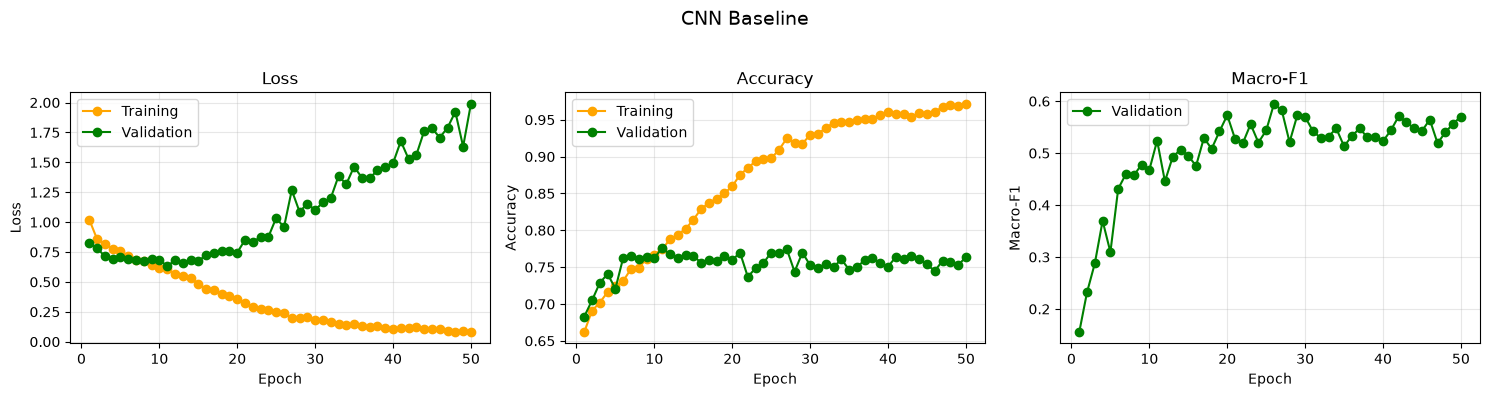

In [33]:
plot_learning_curves(history_0, title="CNN Baseline")

- The baseline CNN achieved a best validation accuracy of 77.57% and a best validation macro-F1 of 0.5948 at epoch 26.
- Training performance continued to improve after this point, while validation performance became increasingly unstable and validation loss generally increased, indicating overfitting.

## Experiment 1: Class-Weighted Cross-Entropy

The baseline model showed a strong bias towards the biggest class. This experiment addresses the class imbalance by assigning larger loss weights to under-represented classes.

The CNN architecture, preprocessing, optimizer, learning rate, batch size, and training procedure remain unchanged. Only the loss function is modified.

The purpose of this experiment is to determine whether class weighting improves performance on minority classes and therefore increases validation macro-F1, while maintaining reasonable overall accuracy.

In [34]:
# calculate the weights using the balanced weighting scheme implemented in scikit-learn, 
# where each class receives a weight inversely proportional to its frequency
class_counts = np.array([228, 359, 769, 80, 779, 4693, 99])

num_samples = class_counts.sum()
num_classes = len(class_counts)

class_weights = num_samples / (num_classes * class_counts)

print("Class balanced weights:")
for class_id, weight in enumerate(class_weights):
    print(f"Class {class_id}: {weight:.4f}")

Class balanced weights:
Class 0: 4.3904
Class 1: 2.7883
Class 2: 1.3017
Class 3: 12.5125
Class 4: 1.2850
Class 5: 0.2133
Class 6: 10.1111


These weights will give greater importance to minority classes during loss calculation and reduce the relative contribution of the majority class. 

The weights are calculated using the training-set class frequencies only.

In [35]:
# convert the weights to a PyTorch tensor
class_weights = torch.tensor(class_weights, dtype=torch.float32)
print(class_weights)

tensor([ 4.3904,  2.7883,  1.3017, 12.5125,  1.2850,  0.2133, 10.1111])


#### Create new loss

We change the loss to use the balanced weights, and need a fresh model and optimizer before training.

In [36]:
model_1 = CNN(num_classes=7)
criterion_1 = nn.CrossEntropyLoss(weight=class_weights)
optimizer_1 = torch.optim.Adam(model_1.parameters(), lr=0.001)

In [37]:
# training loop for Experiment 1
history_1 = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_macro_f1": [],
    "epoch_time": []
}

best_val_macro_f1 = -1
best_epoch = 0

start_time_1 = time.perf_counter()

for epoch in range(num_epochs):
    epoch_start = time.perf_counter()

    train_loss, train_accuracy = train_one_epoch(model_1, train_loader, criterion_1, optimizer_1)
    
    val_loss, val_accuracy, val_macro_f1 = evaluate(model_1, val_loader, criterion_1)

    epoch_time = time.perf_counter() - epoch_start

    history_1["train_loss"].append(train_loss)
    history_1["train_accuracy"].append(train_accuracy)
    history_1["val_loss"].append(val_loss)
    history_1["val_accuracy"].append(val_accuracy)
    history_1["val_macro_f1"].append(val_macro_f1)
    history_1["epoch_time"].append(epoch_time)

    print(
        f"Epoch {epoch + 1:2d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Val Macro-F1: {val_macro_f1:.4f} | "
        f"Time: {epoch_time:.2f}s")

    if val_macro_f1 > best_val_macro_f1:
        best_val_macro_f1 = val_macro_f1
        best_epoch = epoch + 1

training_time_1 = time.perf_counter() - start_time_1

print(f"\nExperiment 1 training time: {training_time_1:.2f}s")
print(f"Best validation macro-F1: {best_val_macro_f1:.4f}")
print(f"Best epoch: {best_epoch}")

Epoch  1/50 | Train Loss: 1.8371 | Train Acc: 0.3108 | Val Loss: 1.6143 | Val Acc: 0.5324 | Val Macro-F1: 0.2738 | Time: 26.65s
Epoch  2/50 | Train Loss: 1.5991 | Train Acc: 0.4199 | Val Loss: 1.5050 | Val Acc: 0.5055 | Val Macro-F1: 0.3075 | Time: 26.77s
Epoch  3/50 | Train Loss: 1.4785 | Train Acc: 0.4798 | Val Loss: 1.4532 | Val Acc: 0.3938 | Val Macro-F1: 0.2667 | Time: 27.08s
Epoch  4/50 | Train Loss: 1.4094 | Train Acc: 0.4862 | Val Loss: 1.3676 | Val Acc: 0.3928 | Val Macro-F1: 0.2867 | Time: 26.75s
Epoch  5/50 | Train Loss: 1.3701 | Train Acc: 0.5055 | Val Loss: 1.2619 | Val Acc: 0.5065 | Val Macro-F1: 0.3629 | Time: 26.33s
Epoch  6/50 | Train Loss: 1.2759 | Train Acc: 0.5169 | Val Loss: 1.1774 | Val Acc: 0.5693 | Val Macro-F1: 0.3885 | Time: 27.00s
Epoch  7/50 | Train Loss: 1.2254 | Train Acc: 0.5323 | Val Loss: 1.2154 | Val Acc: 0.5793 | Val Macro-F1: 0.4339 | Time: 26.18s
Epoch  8/50 | Train Loss: 1.1904 | Train Acc: 0.5480 | Val Loss: 1.1510 | Val Acc: 0.6092 | Val Macro-F1

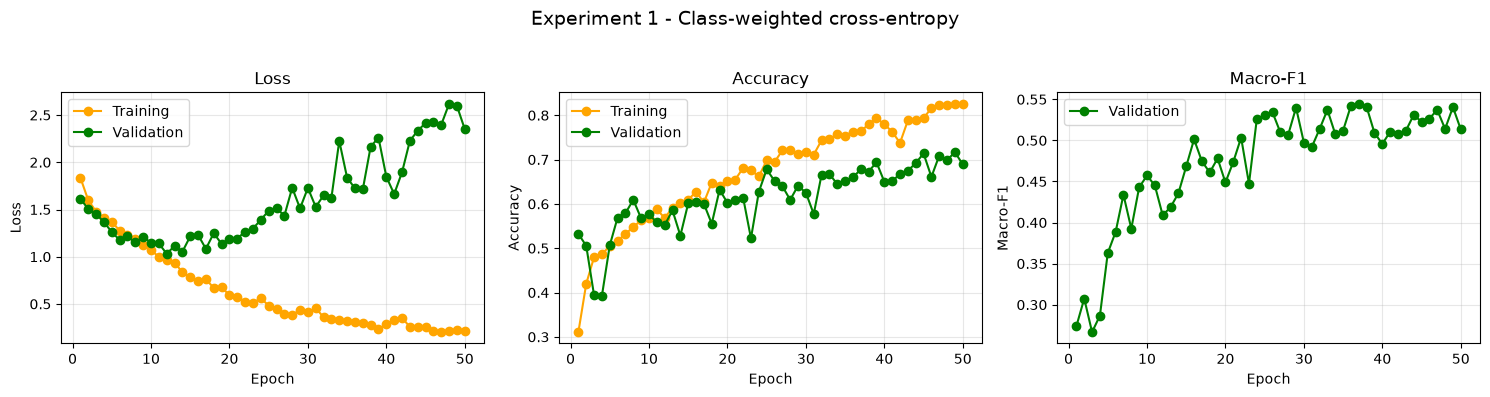

In [38]:
plot_learning_curves(history_1, title="Experiment 1 - Class-weighted cross-entropy")

- Class-weighted cross-entropy did not improve the model relative to the baseline.
- The best validation macro-F1 was 0.5445, compared with 0.5948 for the baseline, while the best validation accuracy was also lower.

Although class weighting was intended to reduce the effect of the majority class, it did not produce better overall balanced classification performance on the validation set. We therefore do not retain this configuration for subsequent experiments.

## Experiment 2: Controlled Oversampling and Data Augmentation

This experiment addresses the class imbalance by increasing the sampling frequency of under-represented classes during training.

We use a weighted random sampler to give minority classes a greater probability of being selected.

We also apply a mild random augmentation to the sampled training images using horizontal flipping and small rotations. This reduces the effect of repeatedly seeing the same minority-class images.

The validation and test sets remain unchanged. The CNN architecture, loss function, optimizer, learning rate, batch size, normalization, and number of epochs are kept consistent with the baseline.

In [39]:
# create the augmented training dataset
# we reuse the normalization statistics we already calculated
transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=mean.tolist(),
        std=std.tolist()
    )
])

train_dataset_aug = DermaMNIST(split="train", size=64, transform=transform_aug, download=False)

In [40]:
# calculate controlled sampling weights
# we use the same class counts we already calculated
class_sampling_weights = 1 / np.sqrt(class_counts)

print("Class sampling weights:")
for class_id, weight in enumerate(class_sampling_weights):
    print(f"Class {class_id}: {weight:.4f}")

Class sampling weights:
Class 0: 0.0662
Class 1: 0.0528
Class 2: 0.0361
Class 3: 0.1118
Class 4: 0.0358
Class 5: 0.0146
Class 6: 0.1005


Here, we use `1 / np.sqrt(class_counts)` rather than `1 / class_counts` to give minority classes more exposure without trying to turn 80 dermatofibromas into the equivalent of 4,693 nevi.

In [41]:
# assign a weight to every training sample
# WeightedRandomSampler needs a weight for each sample, not one weight per class
sample_weights = class_sampling_weights[train_dataset_aug.labels.flatten()]

sample_weights = torch.tensor(
    sample_weights,
    dtype=torch.double
)

In [42]:
# create the sampler and DataLoader

# make DataLoader randomness reproducible
g = torch.Generator()
g.manual_seed(42)

sampler_2 = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True,   # allows minority examples to be selected multiple times during one epoch
    generator=g
)

train_loader_2 = DataLoader(
    train_dataset_aug,
    batch_size=batch_size,
    sampler=sampler_2
)

In [43]:
# create model for Experiment 2
model_2 = CNN(num_classes=7)
criterion_2 = nn.CrossEntropyLoss()
optimizer_2 = torch.optim.Adam(model_2.parameters(), lr=0.001)

In [44]:
# training loop for Experiment 2
history_2 = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_macro_f1": [],
    "epoch_time": []
}

best_val_macro_f1 = -1
best_epoch = 0

start_time_2 = time.perf_counter()

for epoch in range(num_epochs):
    epoch_start = time.perf_counter()

    train_loss, train_accuracy = train_one_epoch(model_2, train_loader_2, criterion_2, optimizer_2)

    val_loss, val_accuracy, val_macro_f1 = evaluate(model_2, val_loader, criterion_2)

    epoch_time = time.perf_counter() - epoch_start

    history_2["train_loss"].append(train_loss)
    history_2["train_accuracy"].append(train_accuracy)
    history_2["val_loss"].append(val_loss)
    history_2["val_accuracy"].append(val_accuracy)
    history_2["val_macro_f1"].append(val_macro_f1)
    history_2["epoch_time"].append(epoch_time)

    print(
        f"Epoch {epoch + 1:2d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Val Macro-F1: {val_macro_f1:.4f} | "
        f"Time: {epoch_time:.2f}s"
    )

    if val_macro_f1 > best_val_macro_f1:
        best_val_macro_f1 = val_macro_f1
        best_epoch = epoch + 1

training_time_2 = time.perf_counter() - start_time_2

print(f"\nExperiment 2 training time: {training_time_2:.2f}s")
print(f"Best validation macro-F1: {best_val_macro_f1:.4f}")
print(f"Best epoch: {best_epoch}")

Epoch  1/50 | Train Loss: 1.4254 | Train Acc: 0.4550 | Val Loss: 0.7915 | Val Acc: 0.7089 | Val Macro-F1: 0.3455 | Time: 28.04s
Epoch  2/50 | Train Loss: 1.1818 | Train Acc: 0.5430 | Val Loss: 0.7701 | Val Acc: 0.7168 | Val Macro-F1: 0.4237 | Time: 27.18s
Epoch  3/50 | Train Loss: 1.1078 | Train Acc: 0.5749 | Val Loss: 0.7663 | Val Acc: 0.6979 | Val Macro-F1: 0.4602 | Time: 27.76s
Epoch  4/50 | Train Loss: 1.0328 | Train Acc: 0.5937 | Val Loss: 0.7656 | Val Acc: 0.6969 | Val Macro-F1: 0.4596 | Time: 27.02s
Epoch  5/50 | Train Loss: 1.0074 | Train Acc: 0.6004 | Val Loss: 0.7725 | Val Acc: 0.6939 | Val Macro-F1: 0.4641 | Time: 27.07s
Epoch  6/50 | Train Loss: 0.9686 | Train Acc: 0.6269 | Val Loss: 0.7074 | Val Acc: 0.7129 | Val Macro-F1: 0.4776 | Time: 27.05s
Epoch  7/50 | Train Loss: 0.9300 | Train Acc: 0.6382 | Val Loss: 0.7130 | Val Acc: 0.7208 | Val Macro-F1: 0.4809 | Time: 27.06s
Epoch  8/50 | Train Loss: 0.9049 | Train Acc: 0.6434 | Val Loss: 0.7028 | Val Acc: 0.7368 | Val Macro-F1

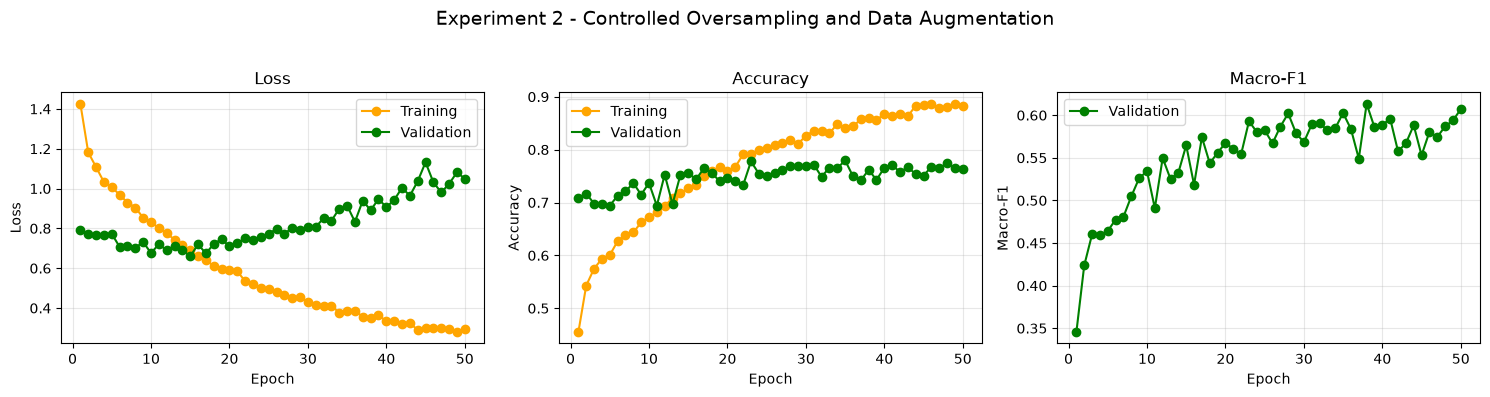

In [45]:
plot_learning_curves(history_2, title="Experiment 2 - Controlled Oversampling and Data Augmentation")

- Controlled oversampling combined with mild data augmentation improved validation macro-F1 compared with the baseline, increasing the best score from 0.5948 to 0.6133.
- Validation accuracy also remained comparable to the baseline, reaching 77.97%.

The result suggests that modifying the effective training distribution and providing augmented examples for under-represented classes is more effective than class-weighted loss for addressing the class imbalance in this dataset.

This configuration is therefore retained as the current best model for further refinement.

## Experiment 3: CNN Architecture Refinement

### Experiment 3a: Adding Batch Normalization

This experiment investigates whether adding Batch Normalization to the convolutional blocks improves model performance.

Batch Normalization is added after each convolutional layer and before the ReLU activation. The rest of the model architecture is kept unchanged.

The oversampling and augmentation strategy from Experiment 2 is retained because it improved validation macro-F1. The loss function, optimizer, learning rate, batch size, normalization, and training procedure also remain unchanged.

The aim is to determine whether the refined architecture can further improve validation performance.

In [46]:
# define the refined architecture
class CNN_BN(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [47]:
# create model for Experiment 3a
model_3a = CNN_BN(num_classes=7)
criterion_3a = nn.CrossEntropyLoss()
optimizer_3a = torch.optim.Adam(model_3a.parameters(), lr=0.001)

In [48]:
# training loop for Experiment 3a (with train_loader from Experiment 2)
history_3a = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_macro_f1": [],
    "epoch_time": []
}

best_val_macro_f1 = -1
best_epoch = 0

start_time_3a = time.perf_counter()

for epoch in range(num_epochs):
    epoch_start = time.perf_counter()

    train_loss, train_accuracy = train_one_epoch(model_3a, train_loader_2, criterion_3a, optimizer_3a)

    val_loss, val_accuracy, val_macro_f1 = evaluate(model_3a, val_loader, criterion_3a)

    epoch_time = time.perf_counter() - epoch_start

    history_3a["train_loss"].append(train_loss)
    history_3a["train_accuracy"].append(train_accuracy)
    history_3a["val_loss"].append(val_loss)
    history_3a["val_accuracy"].append(val_accuracy)
    history_3a["val_macro_f1"].append(val_macro_f1)
    history_3a["epoch_time"].append(epoch_time)

    print(
        f"Epoch {epoch + 1:2d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Val Macro-F1: {val_macro_f1:.4f} | "
        f"Time: {epoch_time:.2f}s"
    )

    if val_macro_f1 > best_val_macro_f1:
        best_val_macro_f1 = val_macro_f1
        best_epoch = epoch + 1

training_time_3a = time.perf_counter() - start_time_3a

print(f"\nExperiment 3a training time: {training_time_3a:.2f}s")
print(f"Best validation macro-F1: {best_val_macro_f1:.4f}")
print(f"Best epoch: {best_epoch}")

Epoch  1/50 | Train Loss: 1.5053 | Train Acc: 0.4481 | Val Loss: 0.7953 | Val Acc: 0.6939 | Val Macro-F1: 0.3723 | Time: 29.30s
Epoch  2/50 | Train Loss: 1.2444 | Train Acc: 0.5219 | Val Loss: 0.8207 | Val Acc: 0.7049 | Val Macro-F1: 0.3982 | Time: 28.50s
Epoch  3/50 | Train Loss: 1.1541 | Train Acc: 0.5359 | Val Loss: 0.7795 | Val Acc: 0.7188 | Val Macro-F1: 0.4213 | Time: 29.02s
Epoch  4/50 | Train Loss: 1.1626 | Train Acc: 0.5353 | Val Loss: 0.7672 | Val Acc: 0.7278 | Val Macro-F1: 0.4201 | Time: 29.47s
Epoch  5/50 | Train Loss: 1.1165 | Train Acc: 0.5552 | Val Loss: 0.8319 | Val Acc: 0.6909 | Val Macro-F1: 0.4150 | Time: 29.16s
Epoch  6/50 | Train Loss: 1.0816 | Train Acc: 0.5686 | Val Loss: 0.7730 | Val Acc: 0.6780 | Val Macro-F1: 0.4914 | Time: 30.69s
Epoch  7/50 | Train Loss: 1.0557 | Train Acc: 0.5734 | Val Loss: 0.7052 | Val Acc: 0.7428 | Val Macro-F1: 0.4729 | Time: 30.10s
Epoch  8/50 | Train Loss: 1.0715 | Train Acc: 0.5784 | Val Loss: 0.8440 | Val Acc: 0.6331 | Val Macro-F1

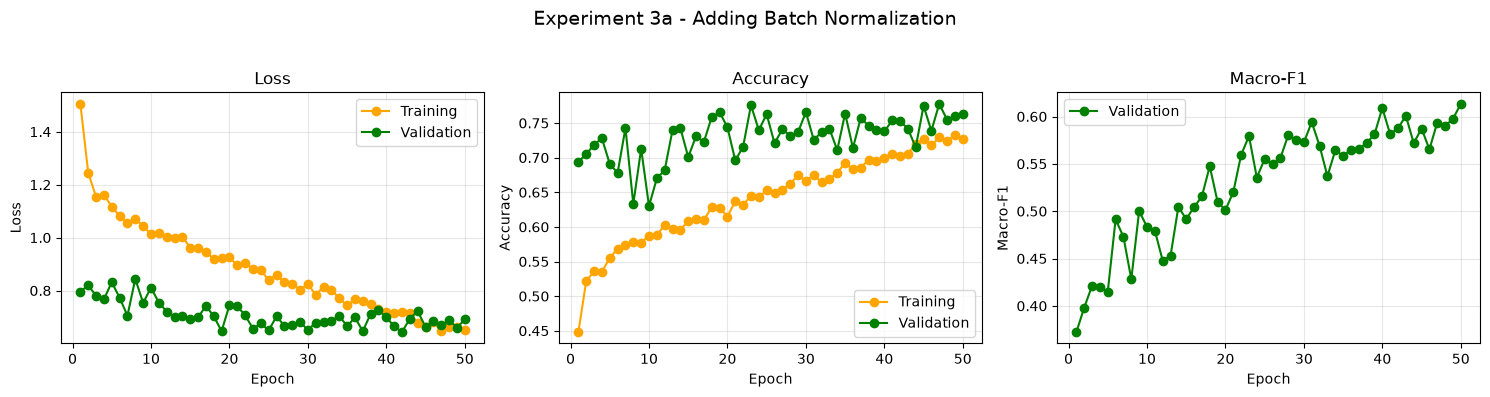

In [49]:
plot_learning_curves(history_3a, title="Experiment 3a - Adding Batch Normalization")

- Adding Batch Normalization did not produce a meaningful improvement in validation performance.
- The best validation macro-F1 was 0.6134, essentially identical to the 0.6133 obtained with Experiment 2.
- However, the training behaviour is different substantially. Unlike the other configurations, the model showed no clear signs of overfitting within the 50-epoch training window, with validation performance continuing to improve while training accuracy remained relatively low.
- Interestigly, validation accuracy is consistently higher than training accuracy. This can be explained with the fact that the model is trained with oversampling + random augmentation + BatchNorm + Dropout, while validation is evaluated on the original, unaugmented validation images, with the model in evaluation mode. So the training accuracy is being measured on a harder/noisier training distribution.

BatchNorm appears to have changed the optimisation behaviour substantially and reduced the apparent overfitting within the 50-epoch training window, but this did not translate into a meaningful improvement in validation performance. Therefore, Model 2 remains the preferred configuration.

### Experiment 3b: Deeper CNN Architecture

This experiment investigates whether increasing the depth of the CNN improves its ability to learn hierarchical visual features.

We add a fourth convolutional block to the baseline architecture, increasing the number of convolutional stages from three to four. The additional block uses 256 filters and is followed by max pooling.

The oversampling and augmentation strategy from Experiment 2 is retained, while the loss function, optimizer, learning rate, batch size, normalization, and training procedure remain unchanged.

In [51]:
# define deeper architecture
class CNN_deep(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [52]:
# create model for Experiment 3b
model_3b = CNN_deep(num_classes=7)
criterion_3b = nn.CrossEntropyLoss()
optimizer_3b = torch.optim.Adam(model_3b.parameters(), lr=0.001)

In [53]:
# training loop for Experiment 3b (with train_loader from Experiment 2)
history_3b = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_macro_f1": [],
    "epoch_time": []
}

best_val_macro_f1 = -1
best_epoch = 0

start_time_3b = time.perf_counter()

for epoch in range(num_epochs):
    epoch_start = time.perf_counter()

    train_loss, train_accuracy = train_one_epoch(model_3b, train_loader_2, criterion_3b, optimizer_3b)

    val_loss, val_accuracy, val_macro_f1 = evaluate(model_3b, val_loader, criterion_3b)

    epoch_time = time.perf_counter() - epoch_start

    history_3b["train_loss"].append(train_loss)
    history_3b["train_accuracy"].append(train_accuracy)
    history_3b["val_loss"].append(val_loss)
    history_3b["val_accuracy"].append(val_accuracy)
    history_3b["val_macro_f1"].append(val_macro_f1)
    history_3b["epoch_time"].append(epoch_time)

    print(
        f"Epoch {epoch + 1:2d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Val Macro-F1: {val_macro_f1:.4f} | "
        f"Time: {epoch_time:.2f}s"
    )

    if val_macro_f1 > best_val_macro_f1:
        best_val_macro_f1 = val_macro_f1
        best_epoch = epoch + 1

training_time_3b = time.perf_counter() - start_time_3b

print(f"\nExperiment 3b training time: {training_time_3b:.2f}s")
print(f"Best validation macro-F1: {best_val_macro_f1:.4f}")
print(f"Best epoch: {best_epoch}")

Epoch  1/50 | Train Loss: 1.4936 | Train Acc: 0.4123 | Val Loss: 0.8998 | Val Acc: 0.6680 | Val Macro-F1: 0.2570 | Time: 31.22s
Epoch  2/50 | Train Loss: 1.2853 | Train Acc: 0.4965 | Val Loss: 0.8662 | Val Acc: 0.6999 | Val Macro-F1: 0.3358 | Time: 31.04s
Epoch  3/50 | Train Loss: 1.1757 | Train Acc: 0.5329 | Val Loss: 0.8147 | Val Acc: 0.6331 | Val Macro-F1: 0.4078 | Time: 31.05s
Epoch  4/50 | Train Loss: 1.1034 | Train Acc: 0.5569 | Val Loss: 0.7715 | Val Acc: 0.7238 | Val Macro-F1: 0.4715 | Time: 31.13s
Epoch  5/50 | Train Loss: 1.0659 | Train Acc: 0.5783 | Val Loss: 0.7284 | Val Acc: 0.7358 | Val Macro-F1: 0.4563 | Time: 31.40s
Epoch  6/50 | Train Loss: 1.0123 | Train Acc: 0.5961 | Val Loss: 0.7498 | Val Acc: 0.7198 | Val Macro-F1: 0.4754 | Time: 31.05s
Epoch  7/50 | Train Loss: 0.9649 | Train Acc: 0.6184 | Val Loss: 0.6827 | Val Acc: 0.7577 | Val Macro-F1: 0.4976 | Time: 31.12s
Epoch  8/50 | Train Loss: 0.9319 | Train Acc: 0.6308 | Val Loss: 0.7735 | Val Acc: 0.6810 | Val Macro-F1

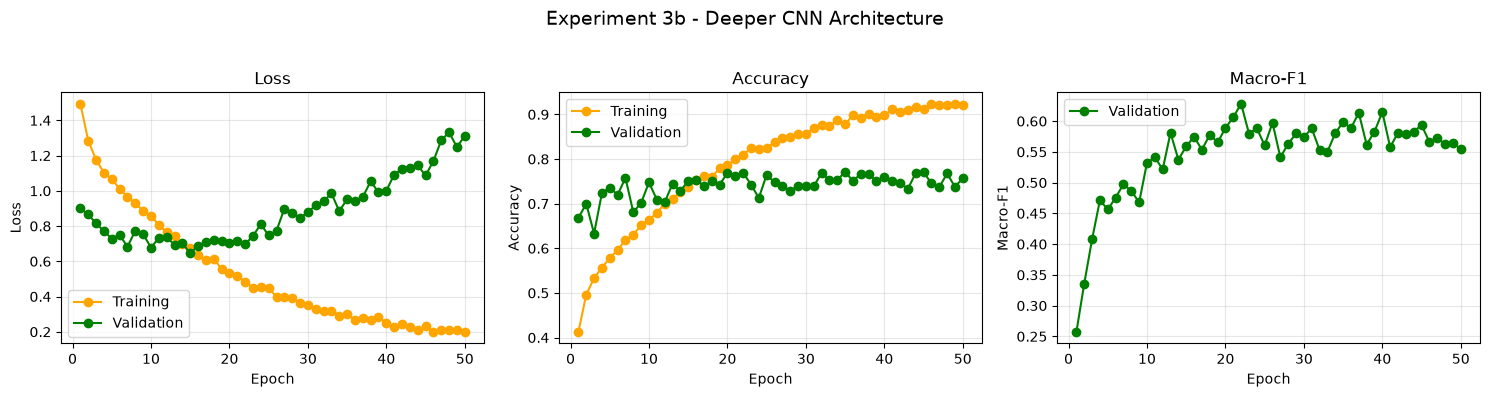

In [54]:
plot_learning_curves(history_3b, title="Experiment 3b - Deeper CNN Architecture")

- Increasing the CNN depth improved validation performance.
- The deeper model achieved the highest validation macro-F1 observed so far, reaching 0.6281 at epoch 22, compared with 0.6133 for Experiment 2.
- However, the additional model capacity also resulted in stronger overfitting. Training accuracy continued to increase after epoch 22, while validation loss increased and validation macro-F1 generally declined.

Despite this overfitting, the improvement in peak validation macro-F1 is meaningful. The deeper CNN is therefore retained as the current best configuration for further experimentation.

## Experiment 4: Optimisation

### Experiment 4a: Learning Rate

This experiment investigates whether reducing the learning rate improves the generalisation of the deeper CNN.

Experiment 3b achieved the best validation macro-F1 so far, but the model showed clear overfitting after its best epoch. We try to reduce the learning rate from 0.001 to 0.0005 to investigate whether a smaller optimisation step leads to more stable training and improved validation performance.

The CNN architecture, oversampling and augmentation strategy, loss function, optimizer, batch size, normalization, and training procedure remain unchanged.

In [57]:
# create model for Experiment 4a
model_4a = CNN_deep(num_classes=7)
criterion_4a = nn.CrossEntropyLoss()
optimizer_4a = torch.optim.Adam(model_4a.parameters(), lr=0.0005)

In [58]:
# training loop for Experiment 4a (with deeper model from 3b and train_loader from Experiment 2)
history_4a = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_macro_f1": [],
    "epoch_time": []
}

best_val_macro_f1 = -1
best_epoch = 0

start_time_4a = time.perf_counter()

for epoch in range(num_epochs):
    epoch_start = time.perf_counter()

    train_loss, train_accuracy = train_one_epoch(model_4a, train_loader_2, criterion_4a, optimizer_4a)

    val_loss, val_accuracy, val_macro_f1 = evaluate(model_4a, val_loader, criterion_4a)

    epoch_time = time.perf_counter() - epoch_start

    history_4a["train_loss"].append(train_loss)
    history_4a["train_accuracy"].append(train_accuracy)
    history_4a["val_loss"].append(val_loss)
    history_4a["val_accuracy"].append(val_accuracy)
    history_4a["val_macro_f1"].append(val_macro_f1)
    history_4a["epoch_time"].append(epoch_time)

    print(
        f"Epoch {epoch + 1:2d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Val Macro-F1: {val_macro_f1:.4f} | "
        f"Time: {epoch_time:.2f}s"
    )

    if val_macro_f1 > best_val_macro_f1:
        best_val_macro_f1 = val_macro_f1
        best_epoch = epoch + 1

training_time_4a = time.perf_counter() - start_time_4a

print(f"\nExperiment 4a training time: {training_time_4a:.2f}s")
print(f"Best validation macro-F1: {best_val_macro_f1:.4f}")
print(f"Best epoch: {best_epoch}")

Epoch  1/50 | Train Loss: 1.5144 | Train Acc: 0.4296 | Val Loss: 0.8984 | Val Acc: 0.6820 | Val Macro-F1: 0.2597 | Time: 31.59s
Epoch  2/50 | Train Loss: 1.3171 | Train Acc: 0.4881 | Val Loss: 0.9041 | Val Acc: 0.6520 | Val Macro-F1: 0.3655 | Time: 32.30s
Epoch  3/50 | Train Loss: 1.1836 | Train Acc: 0.5459 | Val Loss: 0.8363 | Val Acc: 0.7069 | Val Macro-F1: 0.4164 | Time: 31.47s
Epoch  4/50 | Train Loss: 1.1245 | Train Acc: 0.5600 | Val Loss: 0.7484 | Val Acc: 0.7149 | Val Macro-F1: 0.4448 | Time: 30.92s
Epoch  5/50 | Train Loss: 1.0855 | Train Acc: 0.5776 | Val Loss: 0.7320 | Val Acc: 0.7228 | Val Macro-F1: 0.4581 | Time: 30.83s
Epoch  6/50 | Train Loss: 1.0411 | Train Acc: 0.5913 | Val Loss: 0.7399 | Val Acc: 0.7168 | Val Macro-F1: 0.4796 | Time: 30.86s
Epoch  7/50 | Train Loss: 0.9903 | Train Acc: 0.6081 | Val Loss: 0.7028 | Val Acc: 0.7557 | Val Macro-F1: 0.5084 | Time: 31.36s
Epoch  8/50 | Train Loss: 0.9727 | Train Acc: 0.6224 | Val Loss: 0.7321 | Val Acc: 0.6909 | Val Macro-F1

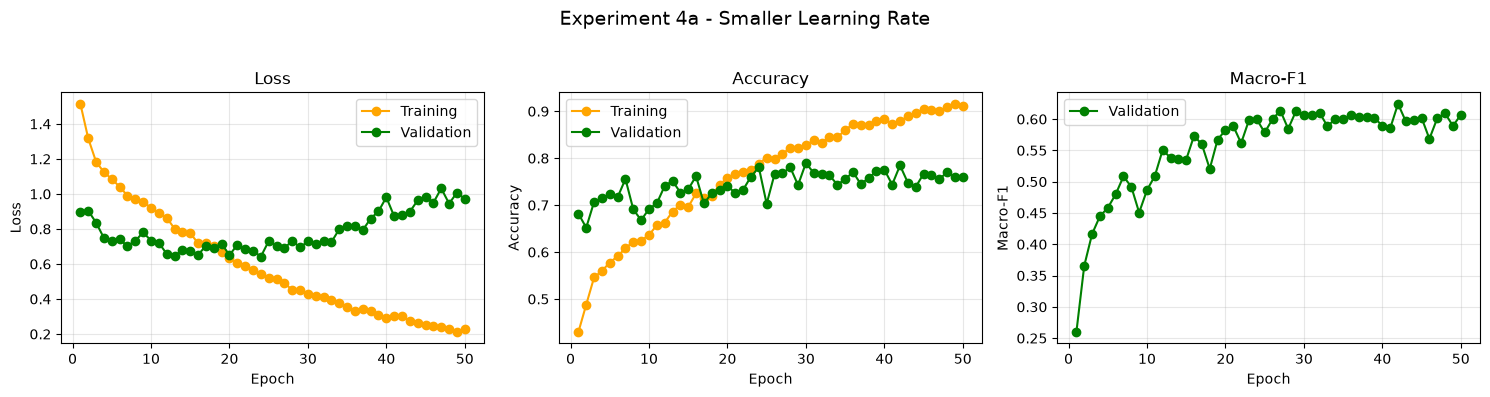

In [59]:
plot_learning_curves(history_4a, title="Experiment 4a - Smaller Learning Rate")

- Reducing the learning rate from 0.001 to 0.0005 changed the training dynamics of the deeper CNN. The model improved more gradually and reached its best validation macro-F1 later, at epoch 42 rather than epoch 22 in Experiment 3b.
- However, the lower learning rate did not improve the best validation macro-F1. The model achieved 0.6243, slightly below the 0.6281 obtained with the original learning rate of 0.001.
- Although Experiment 4a achieved a higher peak validation accuracy of 78.96%, macro-F1 remains the primary metric because of the substantial class imbalance.

The lower learning rate was therefore not retained, and Experiment 3b remains the preferred configuration.

### Experiment 4b: Alternative Optimizer

This experiment investigates whether changing the optimization algorithm improves the generalisation of the deeper CNN.

Experiment 3b achieved the best validation macro-F1 so far, but the model showed clear overfitting after its best epoch. Experiment 4a showed that reducing the learning rate delayed the peak in validation performance but did not improve the best macro-F1.

This experiment therefore returns to the learning rate of 0.001 and replaces Adam with AdamW https://spjosyula2005.medium.com/modern-optimizers-adamw-lion-and-what-actually-works-at-scale-68ffc033713b

The CNN architecture, oversampling and augmentation strategy, loss function, batch size, normalization, and training procedure remain unchanged.

In [60]:
# create model for Experiment 4b
model_4b = CNN_deep(num_classes=7)
criterion_4b = nn.CrossEntropyLoss()
optimizer_4b = torch.optim.AdamW(model_4b.parameters(), lr=0.001, weight_decay=1e-4)

In [61]:
# training loop for Experiment 4b (with deeper model from 3b and train_loader from Experiment 2)
history_4b = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_macro_f1": [],
    "epoch_time": []
}

best_val_macro_f1 = -1
best_epoch = 0

start_time_4b = time.perf_counter()

for epoch in range(num_epochs):
    epoch_start = time.perf_counter()

    train_loss, train_accuracy = train_one_epoch(model_4b, train_loader_2, criterion_4b, optimizer_4b)

    val_loss, val_accuracy, val_macro_f1 = evaluate(model_4b, val_loader, criterion_4b)

    epoch_time = time.perf_counter() - epoch_start

    history_4b["train_loss"].append(train_loss)
    history_4b["train_accuracy"].append(train_accuracy)
    history_4b["val_loss"].append(val_loss)
    history_4b["val_accuracy"].append(val_accuracy)
    history_4b["val_macro_f1"].append(val_macro_f1)
    history_4b["epoch_time"].append(epoch_time)

    print(
        f"Epoch {epoch + 1:2d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Val Macro-F1: {val_macro_f1:.4f} | "
        f"Time: {epoch_time:.2f}s"
    )

    if val_macro_f1 > best_val_macro_f1:
        best_val_macro_f1 = val_macro_f1
        best_epoch = epoch + 1

training_time_4b = time.perf_counter() - start_time_4b

print(f"\nExperiment 4b training time: {training_time_4b:.2f}s")
print(f"Best validation macro-F1: {best_val_macro_f1:.4f}")
print(f"Best epoch: {best_epoch}")

Epoch  1/50 | Train Loss: 1.4927 | Train Acc: 0.4229 | Val Loss: 0.9083 | Val Acc: 0.6859 | Val Macro-F1: 0.2643 | Time: 31.62s
Epoch  2/50 | Train Loss: 1.3115 | Train Acc: 0.4991 | Val Loss: 0.8396 | Val Acc: 0.6889 | Val Macro-F1: 0.3456 | Time: 31.01s
Epoch  3/50 | Train Loss: 1.2017 | Train Acc: 0.5299 | Val Loss: 0.8514 | Val Acc: 0.6570 | Val Macro-F1: 0.4049 | Time: 31.60s
Epoch  4/50 | Train Loss: 1.1267 | Train Acc: 0.5566 | Val Loss: 0.8505 | Val Acc: 0.6580 | Val Macro-F1: 0.4153 | Time: 31.67s
Epoch  5/50 | Train Loss: 1.0956 | Train Acc: 0.5619 | Val Loss: 0.7845 | Val Acc: 0.6839 | Val Macro-F1: 0.4208 | Time: 31.67s
Epoch  6/50 | Train Loss: 1.0337 | Train Acc: 0.5914 | Val Loss: 0.8617 | Val Acc: 0.6720 | Val Macro-F1: 0.4319 | Time: 31.21s
Epoch  7/50 | Train Loss: 0.9793 | Train Acc: 0.6094 | Val Loss: 0.7131 | Val Acc: 0.7089 | Val Macro-F1: 0.4860 | Time: 31.42s
Epoch  8/50 | Train Loss: 0.9487 | Train Acc: 0.6265 | Val Loss: 0.7727 | Val Acc: 0.7089 | Val Macro-F1

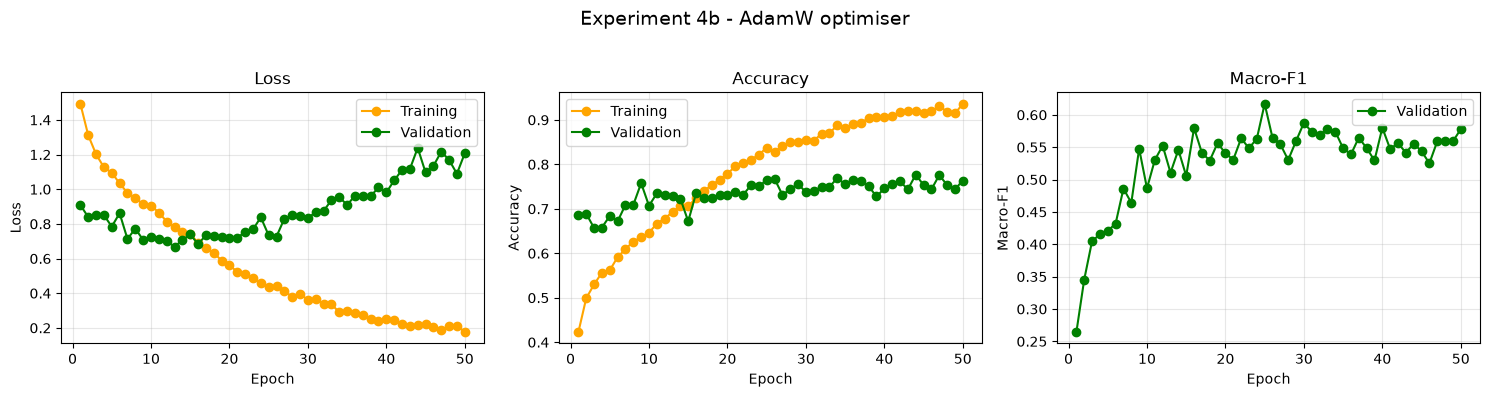

In [63]:
plot_learning_curves(history_4b, title="Experiment 4b - AdamW optimiser")

- Replacing Adam with AdamW and adding a small weight decay did not improve validation performance. The best validation macro-F1 was 0.6170 at epoch 25, below the 0.6281 achieved by Experiment 3b using Adam with a learning rate of 0.001.
- The AdamW model also showed substantial overfitting later in training, with training accuracy increasing to 93.61% while validation loss increased and validation macro-F1 declined.

AdamW was therefore not retained. Experiment 3b remains the best-performing configuration and will be used as the basis for the next stage of experimentation.

## Experiment 5: Focal Loss

This experiment investigates whether replacing standard cross-entropy with focal loss improves classification performance on the imbalanced DermaMNIST dataset.

Focal loss reduces the contribution of well-classified examples and places greater emphasis on difficult examples. This may be beneficial for the current dataset, where the majority class dominates the training data and the minority classes are more difficult to classify.

The deeper CNN architecture and the oversampling and augmentation strategy from Experiment 3b are retained. The optimizer, learning rate, batch size, normalization, and training procedure also remain unchanged.

The focusing parameter is set to γ = 2.0.

In [67]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, inputs, targets):
        # calculate standard cross-entropy loss for each sample
        ce_loss = F.cross_entropy(inputs, targets, reduction="none")
        
        # predicted probability of the correct class
        pt = torch.exp(-ce_loss)
        
        # reduce the contribution of easy, well-classified examples
        # when pt is close to 1, (1 - pt)^gamma approaches 0
        # difficult examples with lower pt receive relatively more weight
        focal_loss = (1 - pt) ** self.gamma * ce_loss

        return focal_loss.mean()

In [68]:
# create model for Experiment 5
model_5 = CNN_deep(num_classes=7)
criterion_5 = FocalLoss(gamma=2.0)
optimizer_5 = torch.optim.Adam(model_5.parameters(), lr=0.001)

In [69]:
# training loop for Experiment 5 (with deeper model from 3b and train_loader from Experiment 2)
history_5 = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_macro_f1": [],
    "epoch_time": []
}

best_val_macro_f1 = -1
best_epoch = 0

start_time_5 = time.perf_counter()

for epoch in range(num_epochs):
    epoch_start = time.perf_counter()

    train_loss, train_accuracy = train_one_epoch(model_5, train_loader_2, criterion_5, optimizer_5)

    val_loss, val_accuracy, val_macro_f1 = evaluate(model_5, val_loader, criterion_5)

    epoch_time = time.perf_counter() - epoch_start

    history_5["train_loss"].append(train_loss)
    history_5["train_accuracy"].append(train_accuracy)
    history_5["val_loss"].append(val_loss)
    history_5["val_accuracy"].append(val_accuracy)
    history_5["val_macro_f1"].append(val_macro_f1)
    history_5["epoch_time"].append(epoch_time)

    print(
        f"Epoch {epoch + 1:2d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Val Macro-F1: {val_macro_f1:.4f} | "
        f"Time: {epoch_time:.2f}s"
    )

    if val_macro_f1 > best_val_macro_f1:
        best_val_macro_f1 = val_macro_f1
        best_epoch = epoch + 1

training_time_5 = time.perf_counter() - start_time_5

print(f"\nExperiment 5 training time: {training_time_5:.2f}s")
print(f"Best validation macro-F1: {best_val_macro_f1:.4f}")
print(f"Best epoch: {best_epoch}")

Epoch  1/50 | Train Loss: 1.0324 | Train Acc: 0.4067 | Val Loss: 0.8405 | Val Acc: 0.5334 | Val Macro-F1: 0.2340 | Time: 31.34s
Epoch  2/50 | Train Loss: 0.8233 | Train Acc: 0.4929 | Val Loss: 0.4834 | Val Acc: 0.6610 | Val Macro-F1: 0.3414 | Time: 31.01s
Epoch  3/50 | Train Loss: 0.7339 | Train Acc: 0.5306 | Val Loss: 0.4346 | Val Acc: 0.7159 | Val Macro-F1: 0.4004 | Time: 31.12s
Epoch  4/50 | Train Loss: 0.6718 | Train Acc: 0.5506 | Val Loss: 0.4503 | Val Acc: 0.6491 | Val Macro-F1: 0.4233 | Time: 31.08s
Epoch  5/50 | Train Loss: 0.6460 | Train Acc: 0.5677 | Val Loss: 0.4586 | Val Acc: 0.7009 | Val Macro-F1: 0.3853 | Time: 31.25s
Epoch  6/50 | Train Loss: 0.6175 | Train Acc: 0.5761 | Val Loss: 0.4384 | Val Acc: 0.7188 | Val Macro-F1: 0.4275 | Time: 31.04s
Epoch  7/50 | Train Loss: 0.5768 | Train Acc: 0.5978 | Val Loss: 0.3752 | Val Acc: 0.7348 | Val Macro-F1: 0.4745 | Time: 31.15s
Epoch  8/50 | Train Loss: 0.5367 | Train Acc: 0.6048 | Val Loss: 0.4104 | Val Acc: 0.6929 | Val Macro-F1

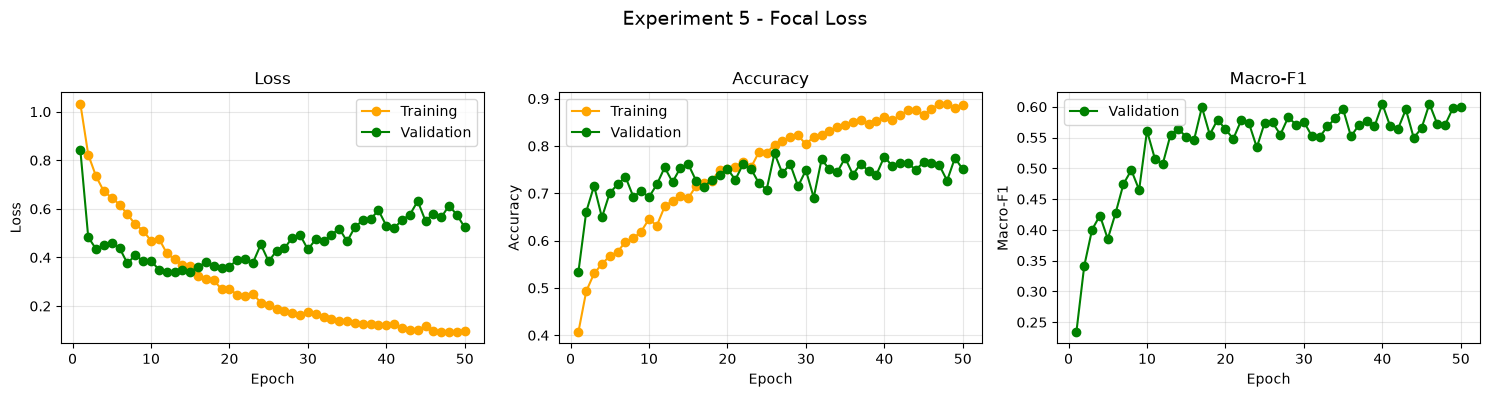

In [70]:
plot_learning_curves(history_5, title="Experiment 5 - Focal Loss")

- Focal loss improved validation macro-F1 compared with the original baseline, but it did not outperform the deeper CNN architecture used in Experiment 3b.
- The best validation macro-F1 was 0.6048 at epoch 46, compared with 0.6281 achieved by Experiment 3b.
- Although focal loss is designed to place greater emphasis on difficult examples, it did not provide a sufficient improvement for the current model and training configuration.
- The model also showed increasing training performance without a corresponding improvement in validation macro-F1 during later epochs.

Focal loss was therefore not retained, and Experiment 3b remains the preferred configuration.